### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import os
from aux import zero_pad
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo

DATA_PATH = './sims_out/test_int_rand1_STD_EXPL_0.0_FIXED_True_L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_FRACI_0.0_SEED_2000_2025-04-04_22:18:14.239638'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
def load_numpy(data_path):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    data = np.stack(data)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of weights

In [14]:
all_w = load_numpy(os.path.join(DATA_PATH, 'weights/net_004_*.npy'))

In [214]:
# shape is 320 integrating trials, each with 1000 time steps
# weights are 46 x 46
all_w.shape

(320, 1000, 46, 46)

In [17]:
def plot_step(run, timestep, v=2):
    scale = 4
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    cbar = axs.matshow(all_w[run, timestep, ...], cmap='bwr', vmin=-v, vmax=v)
    fig.colorbar(cbar, fraction=0.046, pad=0.04)
#     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
    plt.close()
    return fig

In [68]:
img_path = os.path.join(DATA_PATH, 'weight_evo')
make_path_if_not_exists(img_path)

for i in range(0, 320, 1):
    for j in range(0, 1000, 100):
        plot_step(i, j)

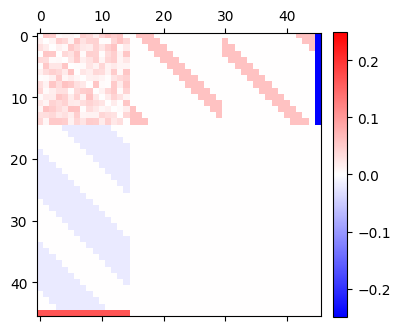

In [20]:
# plot run 0, timestep 0
plot_step(0, 0, v=0.25)

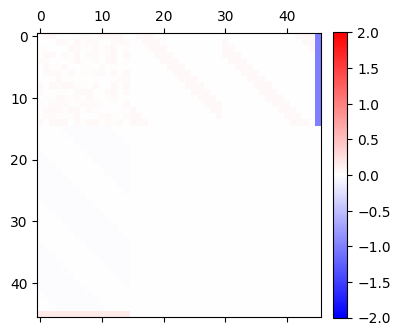

In [18]:
# plot run 0, timestep 0
plot_step(0, 0)

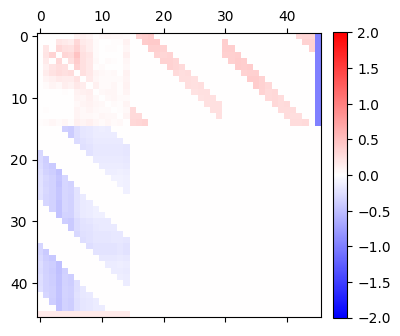

In [21]:
plot_step(20, 0)

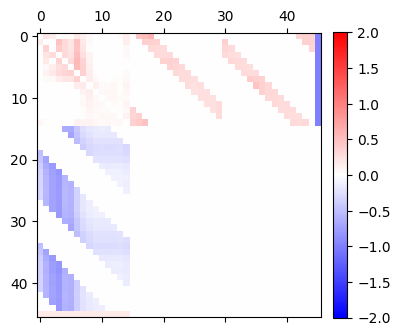

In [22]:
plot_step(30, 0)

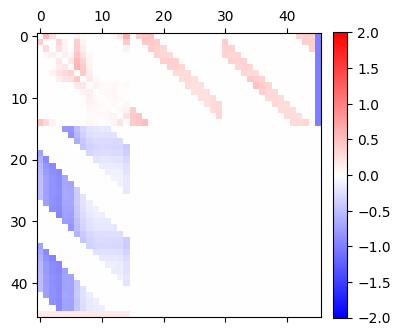

In [23]:
plot_step(40, 0)

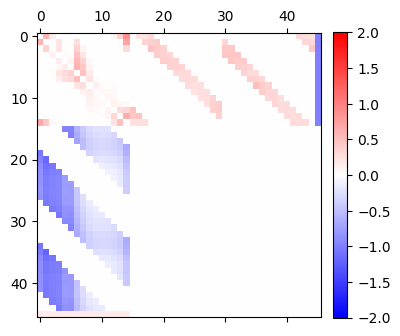

In [24]:
plot_step(50, 0)

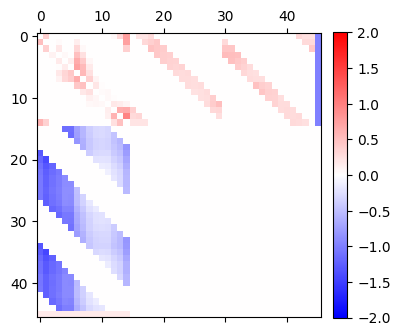

In [25]:
plot_step(60, 0)

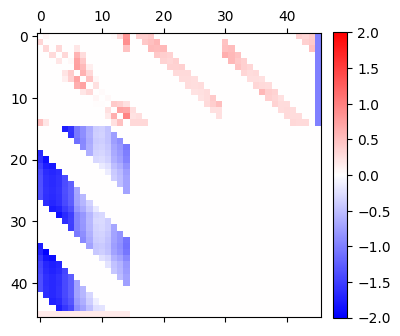

In [26]:
plot_step(100, 0)

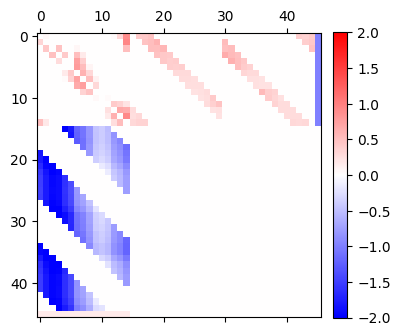

In [27]:
plot_step(120, 0)

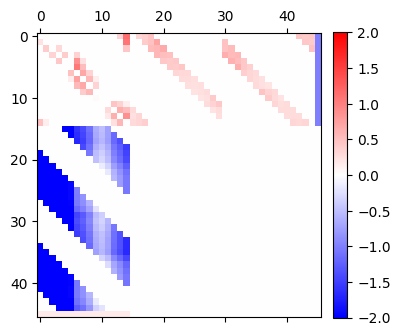

In [28]:
plot_step(200, 0)

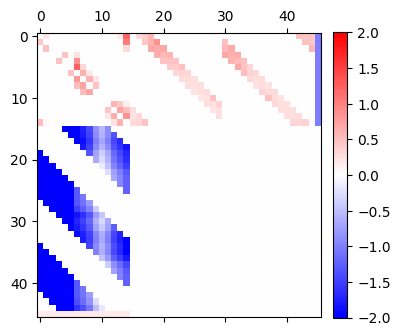

In [29]:
plot_step(300, 0)

### Analysis of neural activity

In [14]:
all_r = load_numpy(os.path.join(DATA_PATH, 'activities/net_004_*.npy'))

In [15]:
# shape of activity matrix is 320 trials, 1000 time steps, 46 units
all_r.shape

(320, 1000, 46)

In [16]:
last_50_r = all_r[-50:, :, :15] # keep only last 50 trials, when plasticity has organized functional circuit
# also keep only 15 units in 'ellipsoid body'

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [17]:
last_50_r = np.transpose(last_50_r, [2, 0, 1])

flattened_data = last_50_r.reshape(last_50_r.shape[0], last_50_r.shape[1] * last_50_r.shape[2], order='C')

pca = PCA()
pc_activities = pca.fit_transform(flattened_data.T)
pc_activities = pc_activities.T.reshape(last_50_r.shape, order='C')

Learned structure leads to low dimensional activity.

Text(0.5, 0, 'PC')

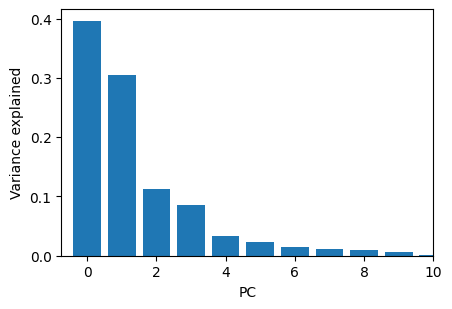

In [18]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

explained_variance_ratios = pca.explained_variance_ratio_
axs.bar(np.arange(explained_variance_ratios.shape[0]), explained_variance_ratios)
axs.set_xlim(-0.75, 10)
axs.set_ylabel('Variance explained')
axs.set_xlabel('PC')

Retrieve target integrated sums. Keep only the last 50 trials.

In [19]:
all_int_values_raw = load_numpy(os.path.join(DATA_PATH, 'integrated_values/net_004_*.npy'))
all_int_values = all_int_values_raw[-50:, :]

Plot last 800 timesteps, when input is active, and color by correct integrated sum.

(15, 50, 1000)


(-1.25, 1.25)

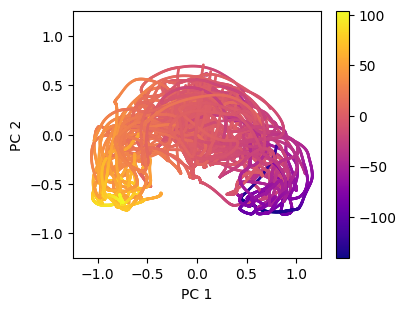

In [20]:
print(pc_activities.shape)

scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(5 * scale, 4 * scale))

min_int_val, max_int_val = np.min(all_int_values), np.max(all_int_values)

for i in range(0, 50, 1):
    cbar = axs.scatter(
        pc_activities[0, i, 200:],
        pc_activities[1, i, 200:],
        cmap='plasma',
        s=1,
        c=all_int_values[i, :],
        vmin=min_int_val,
        vmax=max_int_val,
    )
    if i == 0:
        plt.colorbar(cbar)
axs.set_xlabel('PC 1')
axs.set_ylabel('PC 2')
axs.set_xlim(-1.25, 1.25)
axs.set_ylim(-1.25, 1.25)

Repeat using plotly to visualize in 3 dimensions.

In [22]:
fig = make_subplots(rows=1, cols=1, subplot_titles=('PC space',), specs=[[{'type': 'scene'}]])


min_int_val, max_int_val = np.min(all_int_values), np.max(all_int_values)

for i in range(0, 50, 1):
    # plot first 200 time steps
#     line_style_1 = dict(colorscale='Viridis', color=np.arange(200), cmin=0, cmax=200)
#     fig.append_trace(
#         go.Scatter3d(x=pc_activities[0, i, :200], y=pc_activities[1, i, :200:], z=pc_activities[2, i, :200], mode='lines', line=line_style_1),
#         row=1, col=1)
    
    
    line_style_2 = dict(colorscale='Plasma', color=all_int_values[i, :], cmin=min_int_val, cmax=max_int_val)
    fig.append_trace(
        go.Scatter3d(x=pc_activities[0, i, 200:], y=pc_activities[1, i, 200:], z=pc_activities[2, i, 200:], mode='lines', line=line_style_2),
        row=1, col=1)
#     fig.append_trace(
#         go.Scatter3d(x=all_n[i, :1], y=all_t_d[i, :1], z=all_i_inh[i, :1], mode='markers', marker=dict(color='green', size=5)),
#         row=1, col=1)
#     fig.append_trace(
#         go.Scatter3d(x=all_n[i, -1:], y=all_t_d[i, -1:], z=all_i_inh[i, -1:], mode='markers', marker=dict(color='red', size=5)),
#         row=1, col=1)


fig.update_layout(
    autosize=False,
    width=1000,
    height=800,
    scene=go.Scene(
        xaxis=dict(title='PC 1'),
        yaxis=dict(title='PC 2'),
        zaxis=dict(title='PC 3')
    )
)

(15, 50, 1000)


/var/folders/rp/n8h2l6w51774kxnq18z19s8r0000gn/T/ipykernel_15358/2322049794.py:12: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



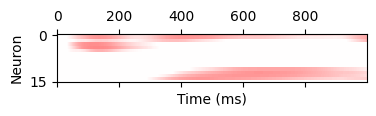

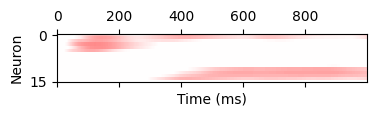

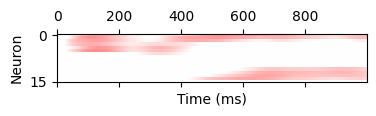

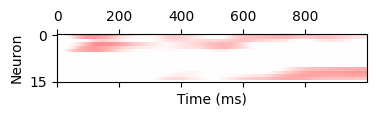

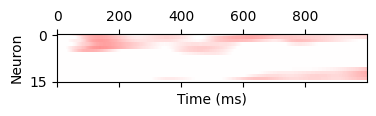

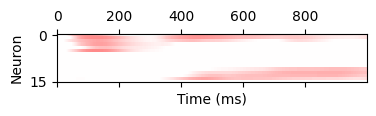

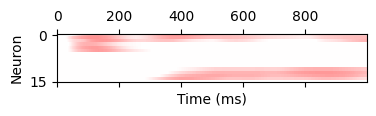

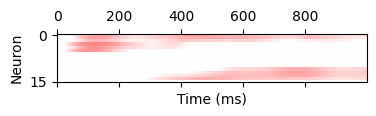

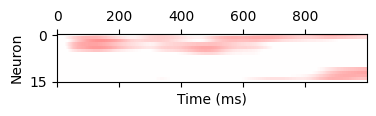

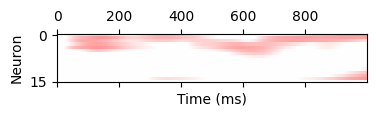

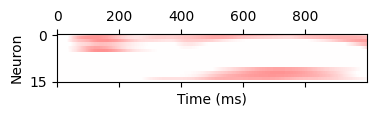

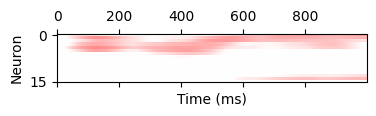

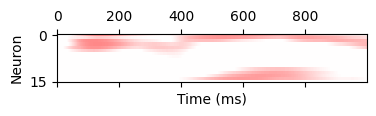

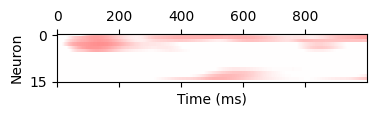

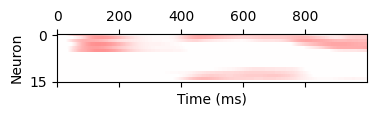

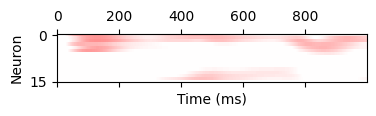

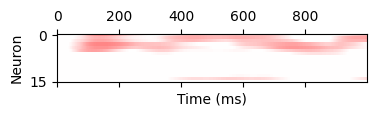

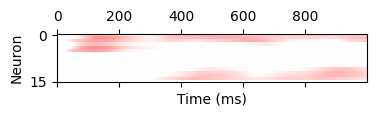

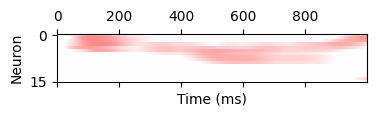

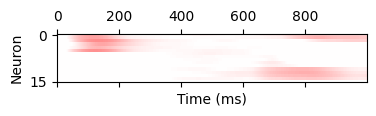

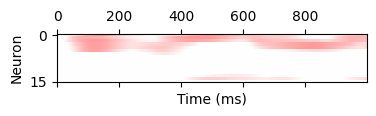

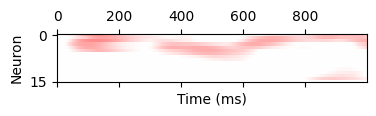

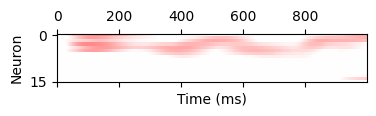

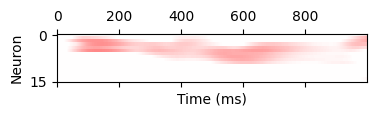

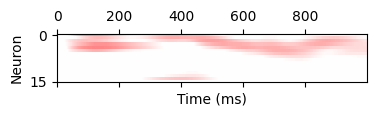

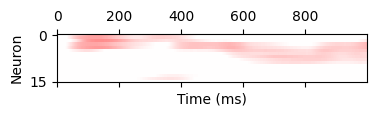

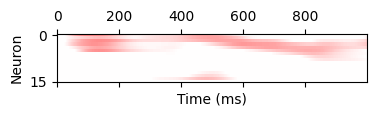

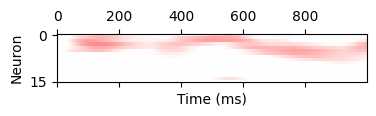

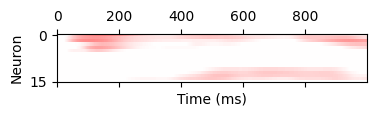

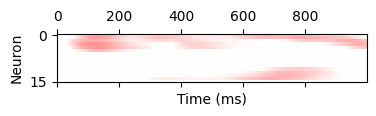

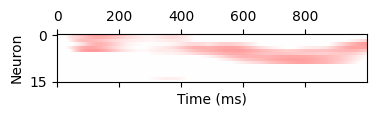

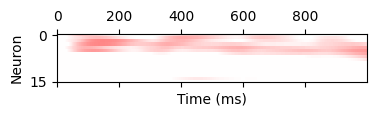

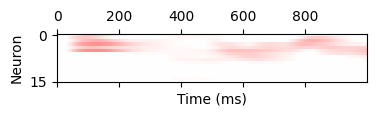

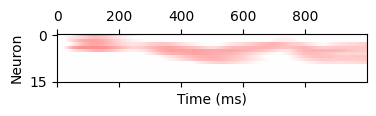

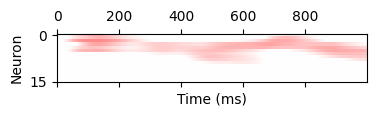

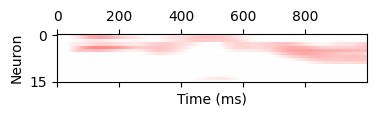

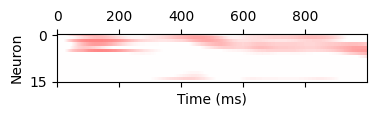

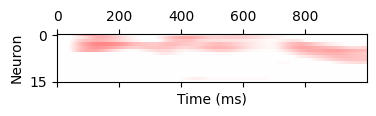

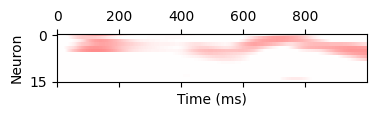

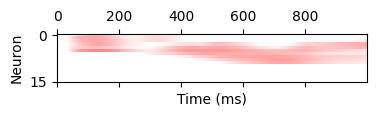

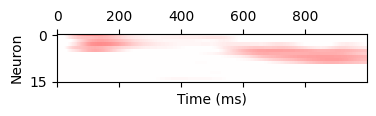

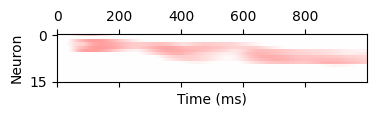

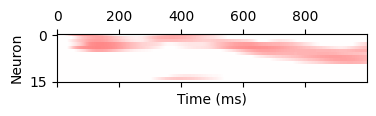

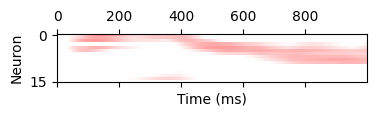

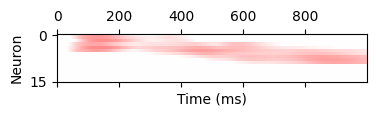

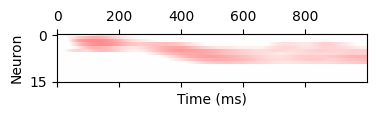

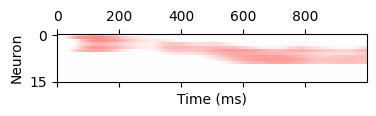

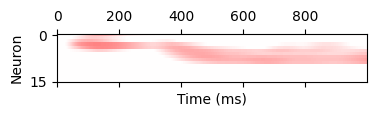

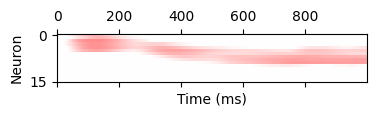

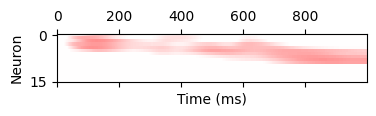

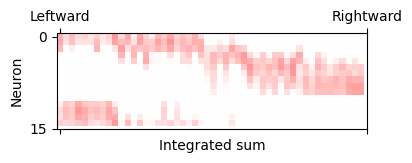

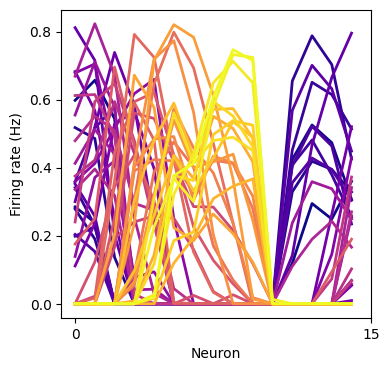

In [11]:
for i in np.argsort(all_int_values):
    pass
#     print(i)
np.argsort(all_int_values)
all_int_values.shape
print(last_50_r.shape)

ending_states = np.empty((last_50_r.shape[0], last_50_r.shape[1]))

for i, j in enumerate(np.argsort(all_int_values[:, -1])):
    scale = 4
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    axs.matshow(last_50_r[:, j, :], cmap='bwr', vmin=-2, vmax=2, aspect=10)
    axs.set_xlabel('Time (ms)')
    axs.set_ylabel('Neuron')
    axs.set_yticks([0, 15])
    
    ending_states[:, i] = last_50_r[:, j, -1]
    
#     fig.savefig(os.path.join(img_path, f'act_{zero_pad(run, 4)}_t_{zero_pad(timestep, 4)}.png'))
#     plt.close()

scale = 4
fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
axs.matshow(ending_states, cmap='bwr', vmin=-2, vmax=2, aspect=1)

axs.set_xlabel('Integrated sum')
axs.set_xticks([0, 50], ['Leftward', 'Rightward'])
axs.set_ylabel('Neuron')
axs.set_yticks([0, 15])

scale = 4
fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))

import matplotlib.pyplot as plt
import numpy as np

plasma = plt.get_cmap("plasma")
colors = [plasma(i / 49)[:3] for i in range(50)]  # 49 to include 0 and 1

for i in range(ending_states.shape[1]):
    axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=2)

axs.set_ylabel('Firing rate (Hz)')
axs.set_xlabel('Neuron')
axs.set_xticks([0, 15])

### Testing usefulness of representation
Grab trials 280-300 and 300-320. Train linear decode on the first set at random points in time. Test on set of activations from the second set.

In [221]:
train_range = slice(280, 300)
test_range = slice(300, 320)
readout_neuron_range = slice(0, 15)

stacked_activities_train = all_r[train_range, 200:, readout_neuron_range]
y_train = all_int_values_raw[train_range, :]
stacked_activities_test = all_r[test_range, 200:, readout_neuron_range]
y_test = all_int_values_raw[test_range, :]

train_acts = np.random.randint(0, 20, size=1000)
train_steps = np.random.randint(0, 800, size=1000)
test_acts = np.random.randint(0, 20, size=1000)
test_steps = np.random.randint(0, 800, size=1000)

X_train = stacked_activities_train[train_acts, train_steps, :]
Y_train = y_train[train_acts, train_steps]

X_test = stacked_activities_test[test_acts, test_steps, :]
Y_test = y_test[test_acts, test_steps]

reg = LinearRegression().fit(X_train, Y_train)
score = reg.score(X_test, Y_test)
print('R^2:', score)

R^2: 0.8890480086833706


Text(0.5, 1.0, 'Predicted vs true integrated sums')

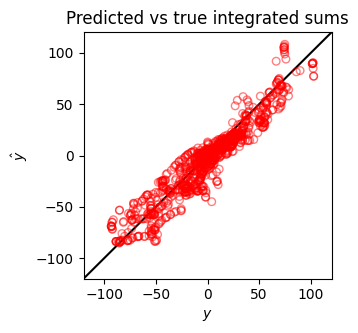

In [223]:
scale = 0.8
fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

axs.plot([-120, 120], [-120, 120], color='black', zorder=0)
axs.scatter(Y_test, reg.predict(X_test), s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
axs.set_xlim(-120, 120)
axs.set_ylim(-120, 120)
axs.set_xlabel(r'$y$')
axs.set_ylabel(r'$\hat{y}$')
axs.set_title('Predicted vs true integrated sums')